In [3]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os
import seaborn as sns

#  Results - Diffusion-Based Data Augmentation: Parameter-Efficient Fine-Tuning of Cheff for Rare Pathologies
This notebook provides a summary of the project's results, including the fine-tuning of the Cheff diffusion model, the performance of pathology classifiers, and an analysis of synthetic data filtering strategies.

## 1. Cheff LoRA Finetuning

The [Cheff](https://github.com/saiboxx/cheff) diffusion model was pretrained on a collection of multiple public adult chest X-ray datasets. [VinDr-PCXR](https://physionet.org/content/vindr-pcxr/1.0.0/) is a pediatric dataset with a fundamentally different imaging distribution (patient size, projection geometry, pathology prevalence) and a relatively small number of annotated training images. This creates a dual challenge: a **domain gap** (adult → pediatric) and **data scarcity** for rare pathologies such as Bronchitis and Bronchiolitis.

To bridge this gap without re-training the full model, we applied **Parameter-Efficient Fine-Tuning (PEFT)** via Low-Rank Adaptation (LoRA). LoRA injects trainable low-rank decomposition matrices into the attention projection layers (`to_q`, `to_k`, `to_v`, `to_out.0`) of Cheff's UNet, with rank $r = 16$ and scaling factor $\alpha = 32$. All original model weights are frozen; only the LoRA adapter weights are updated during training, corresponding to less than 1% of total model parameters.

The adapter was trained for **15 epochs** on the VinDr-PCXR training split using the standard diffusion denoising objective.

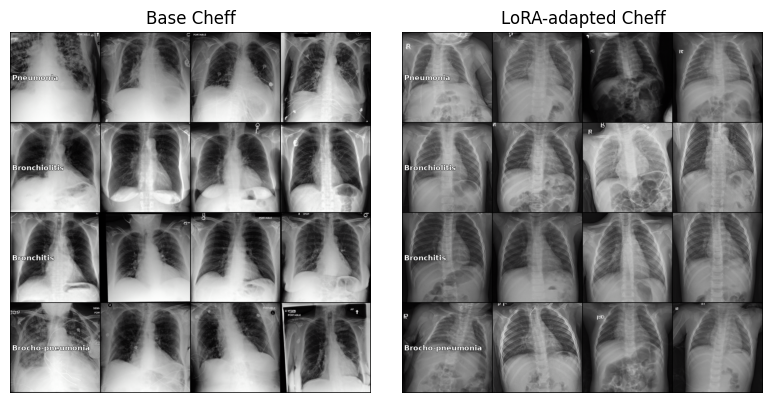

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(plt.imread('cheff_base_pcxr.png'))
axes[0].set_title('Base Cheff')
axes[0].axis('off')
axes[1].imshow(plt.imread('cheff_lora_pcxr.png'))
axes[1].set_title('LoRA-adapted Cheff')
axes[1].axis('off')
plt.tight_layout()
plt.show()

*Sample pediatric chest X-ray generated by th original – and the LoRA-adapted Cheff model, conditioned on the "Pediatric patient with Pneumonia" prompt. The imagaes generated by the fine-tuned model images exhibit plausible pediatric chest anatomy, including proportional cardiac silhouette and lung fields typical of younger patients, demonstrating that fine-tuning has shifted Cheff's output distribution toward the pediatric domain.*

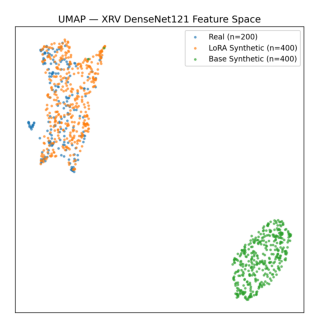

In [9]:
plt.figure(figsize=(4, 4))
plt.imshow(plt.imread('finetune_viz/umap.png'))
plt.axis('off')
plt.show()

### Feature Distribution Analysis

To quantitatively assess the domain adaptation, we extract feature embeddings from a DenseNet121 model pretrained on multi-label chest X-ray classification (torchxrayvision) and project them to 2D via UMAP. Three sets of images are compared: **real** VinDr-PCXR images, images generated by the **base** (un-adapted) Cheff model, and images generated by the **LoRA-adapted** model.

The UMAP plot above shows that LoRA-generated images form a cluster that closely overlaps with the real image distribution. In contrast, images from the base model occupy a distinct and largely disjoint region of feature space, confirming that the un-adapted model produces images far outside the pediatric imaging manifold.

In [10]:
fdd_df = pd.read_csv('finetune_viz/fdd.csv')
fdd_df['comparison'] = fdd_df['comparison'].map({
    'real_vs_lora': 'Real vs LoRA',
    'real_vs_base': 'Real vs Base',
    'real_self_check': 'Real vs Real (self-check)',
})
fdd_df.columns = ['Comparison', '# Real', '# Synthetic', 'FDD']
display(fdd_df.style.hide(axis='index').format({'FDD': '{:.4f}'}))

Comparison,# Real,# Synthetic,FDD
Real vs LoRA,400,400,1.6111
Real vs Base,400,400,17.8052
Real vs Real (self-check),400,400,0.6635


The **Fréchet DenseNet Distance (FDD)** is computed as the Fréchet distance between Gaussian fits of the DenseNet121 feature distributions — analogous to FID but using a task-specific feature extractor more appropriate for medical imaging.

The LoRA-adapted model achieves an FDD of **1.61** against the real distribution, compared to **17.81** for the base model — a reduction of approximately **90%**. The self-check FDD of **0.66** (computed between two disjoint halves of the real dataset) establishes a near-zero lower bound, confirming the metric behaves correctly. Together, these results quantitatively validate the qualitative observation from the UMAP plot: LoRA fine-tuning successfully closes the domain gap between the adult-pretrained generative model and the pediatric imaging distribution.

## 2. Classifier Test Performance
To assess the impact of diffusion-based data augmentation on clinical applications, we evaluate the performance of a pathology classifier, pretrained via [TorchXRayVision](https://torchxrayvision.readthedocs.io/en/latest/index.html), on the [VinDr-PCXR](https://physionet.org/content/vindr-pcxr/1.0.0/) pediatric dataset. 

We compare the model's performance across three settings:

*   **Baseline**: Model trained solely on the VinDr-PCXR pediatric dataset.
*   **Synthetic**: Model trained on the dataset augmented with unfiltered synthetic images generated from the LoRA-adapted Cheff model.
*   **Synthetic Filtered**: Model trained with real data augmented by synthetic samples selected via an Oracle-based filtering strategy.

For more details on the training runs have a look at the classifier/runs folder. It contains more details on metrics, the output of the sbatch files and an image of the training curves.   

In [38]:
def load_metrics(path):
    with open(path, 'r') as f:
        return json.load(f)

runs_root = '../classifier/runs'
baseline_metrics = load_metrics(os.path.join(runs_root, 'baseline_slurm_ref/metrics.json'))
synthetic_metrics = load_metrics(os.path.join(runs_root, 'synthetic_slurm_ref/metrics.json'))
synthetic_filtered_metrics = load_metrics(os.path.join(runs_root, 'synthetic_filtered_slurm_ref/metrics.json'))

df_baseline = pd.DataFrame(baseline_metrics).T
df_synthetic = pd.DataFrame(synthetic_metrics).T
df_filtered = pd.DataFrame(synthetic_filtered_metrics).T

auroc_comparison = pd.DataFrame({
    'Baseline': df_baseline['auroc'],
    'Synthetic': df_synthetic['auroc'],
    'Synthetic Filtered': df_filtered['auroc']
}).T

auroc_comparison['Mean AUC'] = auroc_comparison.mean(axis=1)

print("AUROC Comparison: Pathologies and Macro Mean")
display(auroc_comparison.style.highlight_max(axis=0, color='grey'))

AUROC Comparison: Pathologies and Macro Mean


,No finding,Bronchitis,Brocho-pneumonia,Bronchiolitis,Pneumonia,Other disease,Mean AUC
Baseline,0.719009,0.686295,0.769539,0.696948,0.763787,0.622819,0.709733
Synthetic,0.711826,0.669345,0.762802,0.656287,0.748299,0.592621,0.690197
Synthetic Filtered,0.718772,0.695026,0.770509,0.698444,0.758702,0.635549,0.712834


Augmenting the training set with the full synthetic dataset resulted in a slight performance degradation, only by applying Oracle filtering we successfully recovered and for some pathologies even surpassed the baseline performance. 

This suggests that a filtering strategy is crucial to ensure the quality of the synthetic samples. The importance of this step stem from the challenging conditions of the Cheff-LoRA finetuning, specifically the adult-to-pediatric domain gap and the limited size of the VinDr-PCXR dataset. These constraints may result in Cheff having a less robust representation of the pediatric domain, making rigorous sample selection essential.

While our current results do not reach the performance levels of [current benchmarks](https://pmc.ncbi.nlm.nih.gov/articles/PMC11312211/) on the VinDr-PCXR Dataset, they seem in line with their results. 

### Oracle Filtering of Synthetic Data

The Oracle filtering strategy employs our baseline model to validate synthetic samples. Only synthetic sameples are kept for which the baseline's predicted probability of the given pathology surpassed the threshold of 0.7.

The distribution of predicted probabilities for synthetic data varies significantly across pathologies. This likely stems from two factors: the relative complexity of synthesizing (or detecting) specific pathological features, and the inductive biases of the pretrained torchxrayvision classifier, which may be more familiar with certain conditions like Pneumonia due to its original training distribution.

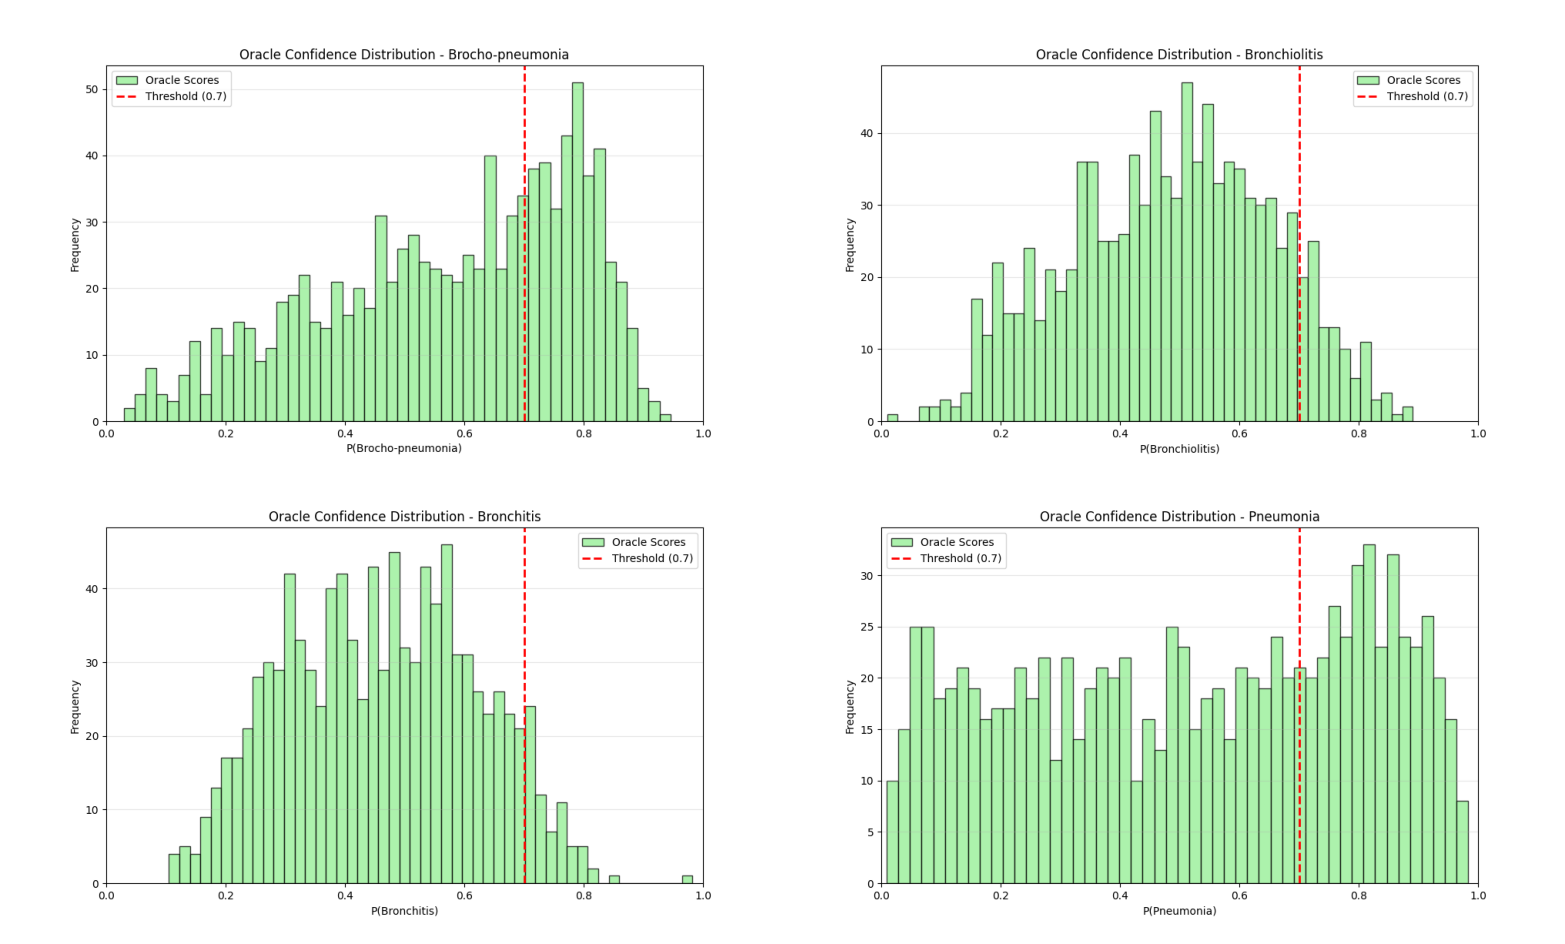

In [37]:
import matplotlib.pyplot as plt
import os

filter_runs_dir = '../classifier/runs/synthetic_filtered_slurm_ref'
oracle_images = [
    'oracle_distribution_Brocho-pneumonia.png',
    'oracle_distribution_Bronchiolitis.png',
    'oracle_distribution_Bronchitis.png',
    'oracle_distribution_Pneumonia.png'
]

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for i, img_name in enumerate(oracle_images):
    img_path = os.path.join(filter_runs_dir, img_name)
    img = plt.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

### Oracle Filtering Statistics

The table below summarizes the yield rates and average confidence scores for each pathology during the Oracle filtering process. Pneumonia and Broncho-pneumonia show significantly higher yield rates, suggesting that the model more reliably synthesizes features characteristic of these conditions, or that the baseline classifier is more sensitive to them.

In [4]:
filter_runs_dir = '../classifier/runs/synthetic_filtered_slurm_ref'
metadata_files = [f for f in os.listdir(filter_runs_dir) if f.startswith('filter_oracle_metadata_')]
oracle_results = []
for f in metadata_files:
    with open(os.path.join(filter_runs_dir, f), 'r') as jf:
        oracle_results.append(json.load(jf))

df_oracle = pd.DataFrame(oracle_results)
df_oracle = df_oracle[['target_pathology', 'total_evaluated', 'accepted', 'yield_rate', 'score_mean']]
df_oracle.columns = ['Pathology', 'Total', 'Accepted', 'Yield Rate', 'Mean Score']
display(df_oracle.style.hide(axis='index').format({'Yield Rate': '{:.2%}', 'Mean Score': '{:.4f}'}))

Pathology,Total,Accepted,Yield Rate,Mean Score
Brocho-pneumonia,1000,365,36.50%,0.5746
Bronchiolitis,1000,108,10.80%,0.4837
Bronchitis,1000,68,6.80%,0.4615
Pneumonia,1000,345,34.50%,0.5203
